In [2]:
import pickle
import numpy as np
import pandas as pd
from numpy.linalg import slogdet, solve
from itertools import combinations


with open("./data/task_df_dict.pkl", "rb") as f:
    task_df_dict = pickle.load(f)

In [4]:
def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    X1 = X1[:, None, :]
    X2 = X2[None, :, :]
    sqdist = np.sum((X1 - X2) ** 2, axis=-1)
    return variance * np.exp(-0.5 * sqdist / lengthscale**2)


def gp_posterior_cov(X_train, y_train, X_star, noise=1e-2):
    K = rbf_kernel(X_train, X_train)
    Ks = rbf_kernel(X_train, X_star)
    Kss = rbf_kernel(X_star, X_star)

    Ky = K + noise * np.eye(len(X_train))
    K_post = Kss - Ks.T @ solve(Ky, Ks)
    return K_post

def gaussian_mi(Sigma_x, Sigma_y, Sigma_xy):
    """
    Computes I(X;Y) for joint Gaussian
    """
    top = np.block([[Sigma_x, Sigma_xy],
                    [Sigma_xy.T, Sigma_y]])

    _, logdet_x = slogdet(Sigma_x)
    _, logdet_y = slogdet(Sigma_y)
    _, logdet_joint = slogdet(top)

    return 0.5 * (logdet_x + logdet_y - logdet_joint)



In [6]:
def build_reference_grid(task_df_dict, n_points=20):
    X_all = pd.concat(task_df_dict.values())
    grid = []

    for col in ["feedrate", "gas_pressure", "focal_position"]:
        lo, hi = X_all[col].min(), X_all[col].max()
        grid.append(np.linspace(lo, hi, n_points))

    mesh = np.meshgrid(*grid)
    X_star = np.vstack([m.ravel() for m in mesh]).T
    return X_star

def task_mutual_information_matrix(task_df_dict, noise=1e-2):
    tasks = list(task_df_dict.keys())
    T = len(tasks)

    X_star = build_reference_grid(task_df_dict)

    # GP posterior covariances per task
    post_covs = {}

    for task in tasks:
        df = task_df_dict[task]
        X = df[["feedrate", "gas_pressure", "focal_position"]].values
        y = df["burr_evaluated"].values
        post_covs[task] = gp_posterior_cov(X, y, X_star, noise)

    # MI matrix
    MI = np.zeros((T, T))

    for i, j in combinations(range(T), 2):
        ti, tj = tasks[i], tasks[j]

        # Independent posteriors ⇒ cross-cov via shared prior
        K_star = rbf_kernel(X_star, X_star)
        Sigma_xy = K_star - post_covs[ti] - post_covs[tj]

        mi = gaussian_mi(post_covs[ti], post_covs[tj], Sigma_xy)
        MI[i, j] = MI[j, i] = mi

    return pd.DataFrame(MI, index=tasks, columns=tasks)



In [7]:
build_reference_grid(task_df_dict)

array([[  1.        ,   0.5       , -12.1       ],
       [  1.        ,   0.5       , -10.97368421],
       [  1.        ,   0.5       ,  -9.84736842],
       ...,
       [ 19.        ,  24.        ,   7.04736842],
       [ 19.        ,  24.        ,   8.17368421],
       [ 19.        ,  24.        ,   9.3       ]], shape=(8000, 3))

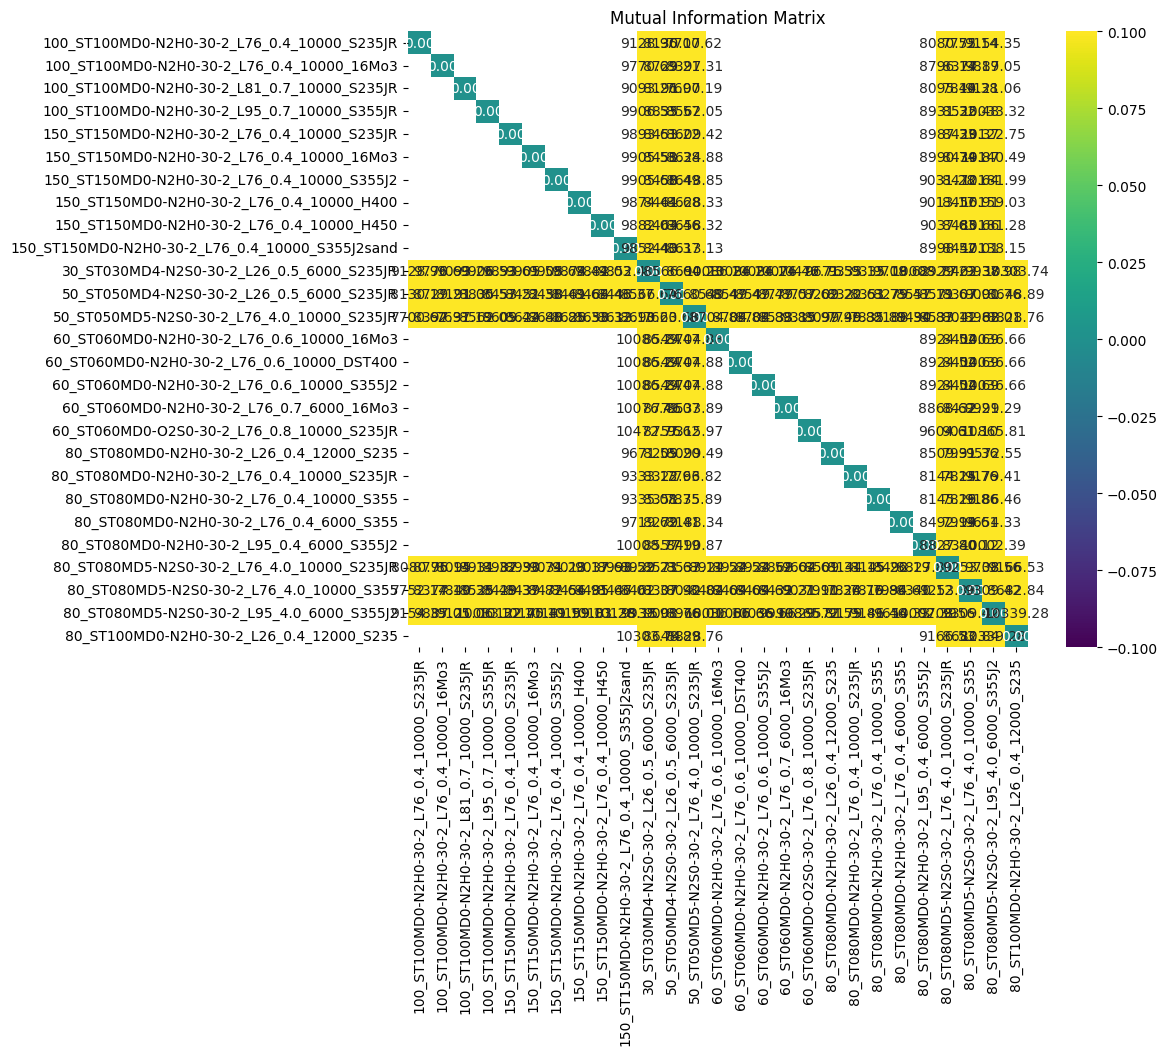

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Redefine to accept n_points
def task_mutual_information_matrix_v2(task_df_dict, noise=1e-2, n_points=5):
    tasks = list(task_df_dict.keys())
    T = len(tasks)

    # Use the existing build_reference_grid but with custom n_points
    # We need to call build_reference_grid from the notebook context.
    # But build_reference_grid takes n_points as argument in the definition I saw earlier?
    # Let's check cell 3 again.
    
    X_star = build_reference_grid(task_df_dict, n_points=n_points)

    # GP posterior covariances per task
    post_covs = {}

    for task in tasks:
        df = task_df_dict[task]
        X = df[["feedrate", "gas_pressure", "focal_position"]].values
        y = df["burr_evaluated"].values
        post_covs[task] = gp_posterior_cov(X, y, X_star, noise)

    # MI matrix
    MI = np.zeros((T, T))
    
    # Pre-calculate K_star
    K_star = rbf_kernel(X_star, X_star)

    for i, j in combinations(range(T), 2):
        ti, tj = tasks[i], tasks[j]

        # Logic from original function
        # Note: This formula for Sigma_xy seems specific to the user's method
        Sigma_xy = K_star - post_covs[ti] - post_covs[tj]

        mi = gaussian_mi(post_covs[ti], post_covs[tj], Sigma_xy)
        MI[i, j] = MI[j, i] = mi

    return pd.DataFrame(MI, index=tasks, columns=tasks)

# Compute Matrix
# note: n_points=20 results in 8000 points, which is too large for O(N^3). 
# Using n_points=5 (125 points) or 8 (512 points) is safer for quick viz.
mi_df = task_mutual_information_matrix_v2(task_df_dict, n_points=8)

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(mi_df, annot=True, cmap="viridis", fmt=".2f")
plt.title("Mutual Information Matrix")
plt.show()

In [ ]:
print(mi_df)
print("Has NaNs:", mi_df.isna().any().any())
print("Has Infs:", np.isinf(mi_df.values).any())
print("Min:", mi_df.min().min())
print("Max:", mi_df.max().max())